# Phase 4 - Model Accuracy And Precision Evaluation


Forward Selected Features: ['num_devices', 'latency', 'packet_loss', 'noise_level', 'router_load']

Backward Selected Features: ['num_devices', 'latency', 'packet_loss', 'noise_level', 'router_load']

--- ACCURACY ---
Logistic Regression: 0.6875
KNN: 0.875
Decision Tree: 0.6875

--- F1 SCORE ---
Logistic Regression: 0.6704545454545454
KNN: 0.8770833333333334
Decision Tree: 0.665719696969697

--- CLASSIFICATION REPORT (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.57      1.00      0.73         4
           1       0.75      0.43      0.55         7
           2       0.80      0.80      0.80         5

    accuracy                           0.69        16
   macro avg       0.71      0.74      0.69        16
weighted avg       0.72      0.69      0.67        16



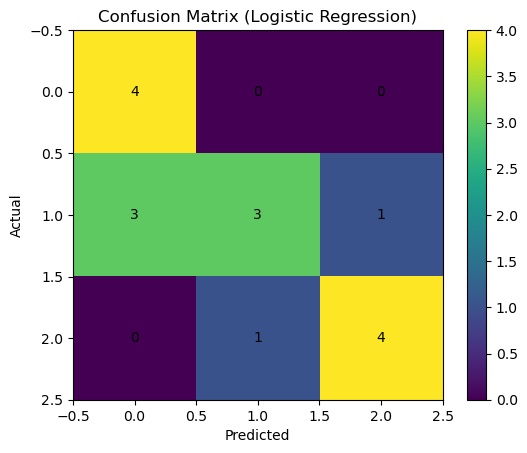


--- SAMPLE PREDICTIONS ---
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 2, Predicted: 2
Actual: 2, Predicted: 2


In [4]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SequentialFeatureSelector

import matplotlib.pyplot as plt

# =====================================================
# 2. LOAD DATA
# =====================================================
df = pd.read_csv("cleaned_wifi_data.csv")

# Encode target
df['congestion_level'] = df['congestion_level'].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# =====================================================
# 3. BALANCE DATASET
# =====================================================
df_low = df[df['congestion_level'] == 0]
df_med = df[df['congestion_level'] == 1]
df_high = df[df['congestion_level'] == 2]

min_size = min(len(df_low), len(df_med), len(df_high))

df_balanced = pd.concat([
    df_low.sample(min_size, random_state=42),
    df_med.sample(min_size, random_state=42),
    df_high.sample(min_size, random_state=42)
])

df_balanced = df_balanced.sample(frac=1, random_state=42)

# =====================================================
# 4. FEATURE & TARGET SPLIT
# =====================================================
X = df_balanced.drop("congestion_level", axis=1)
y = df_balanced["congestion_level"]

# =====================================================
# 5. SCALING
# =====================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# =====================================================
# 6. FEATURE SELECTION
# =====================================================
model_fs = LogisticRegression(max_iter=1000)

# Forward Selection
forward_selector = SequentialFeatureSelector(
    model_fs, n_features_to_select=5, direction='forward'
)
forward_selector.fit(X_scaled, y)

forward_features = X.columns[forward_selector.get_support()]
print("\nForward Selected Features:", list(forward_features))

# Backward Selection
backward_selector = SequentialFeatureSelector(
    model_fs, n_features_to_select=5, direction='backward'
)
backward_selector.fit(X_scaled, y)

backward_features = X.columns[backward_selector.get_support()]
print("\nBackward Selected Features:", list(backward_features))

# Use forward features
X_selected = X_scaled[forward_features]

# =====================================================
# 7. TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# =====================================================
# 8. MODELS
# =====================================================
lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)

lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_dt = dt.predict(X_test)

# =====================================================
# 9. ACCURACY
# =====================================================
print("\n--- ACCURACY ---")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

# =====================================================
# 10. F1 SCORE
# =====================================================
print("\n--- F1 SCORE ---")
print("Logistic Regression:", f1_score(y_test, y_pred_lr, average='weighted'))
print("KNN:", f1_score(y_test, y_pred_knn, average='weighted'))
print("Decision Tree:", f1_score(y_test, y_pred_dt, average='weighted'))

# =====================================================
# 11. CLASSIFICATION REPORT
# =====================================================
print("\n--- CLASSIFICATION REPORT (Logistic Regression) ---")
print(classification_report(y_test, y_pred_lr))

# =====================================================
# 12. CONFUSION MATRIX (NO SEABORN)
# =====================================================
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

# =====================================================
# 13. SAMPLE PREDICTIONS
# =====================================================
print("\n--- SAMPLE PREDICTIONS ---")
for i in range(5):
    print(f"Actual: {y_test.iloc[i]}, Predicted: {y_pred_lr[i]}")